In [1]:
from google.colab import files
uploaded = files.upload()


Saving baseline_features_v4_segment_split_train_val_test.npz to baseline_features_v4_segment_split_train_val_test.npz


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import os

data = np.load("baseline_features_v4_segment_split_train_val_test.npz", allow_pickle=True)

X_train = data["X_train"]
y_train = data["y_train"]
X_val   = data["X_val"]
y_val   = data["y_val"]
X_test  = data["X_test"]
y_test  = data["y_test"]
modes   = list(data["modes"])

print("Shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape,   "y_val  :", y_val.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)
print("Modes:", modes)

mode_to_idx = {m:i for i,m in enumerate(modes)}
y_train_i = np.array([mode_to_idx[y] for y in y_train], dtype=np.int64)
y_test_i  = np.array([mode_to_idx[y] for y in y_test],  dtype=np.int64)

# NOTE: y_val contains no "car" windows; map only what exists
y_val_i = np.array([mode_to_idx[y] for y in y_val], dtype=np.int64)

# Add channel dim for Conv2D
X_train = X_train[..., np.newaxis]
X_val   = X_val[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

print("After expand dims:")
print("X_train:", X_train.shape)


Shapes:
X_train: (360, 200, 7) y_train: (360,)
X_val  : (1019, 200, 7) y_val  : (1019,)
X_test : (440, 200, 7) y_test : (440,)
Modes: ['train', 'subway', 'car', 'bus', 'walk']
After expand dims:
X_train: (360, 200, 7, 1)


In [4]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1], X_train.shape[2], 1)),
    tf.keras.layers.Conv2D(16, (5,1), activation="relu", padding="same"),
    tf.keras.layers.MaxPool2D((2,1)),
    tf.keras.layers.Conv2D(32, (5,1), activation="relu", padding="same"),
    tf.keras.layers.MaxPool2D((2,1)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(modes), activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 7, 16)     │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 7, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 7, 32)     │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 7, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 11200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       716,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 719,877 (2.75 MB)

 Trainable params: 719,877 (2.75 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - accuracy: 0.7104 - loss: 0.7772 - val_accuracy: 0.7419 - val_loss: 5.3621
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.9977 - loss: 0.0228 - val_accuracy: 0.7419 - val_loss: 10.5593
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.9961 - loss: 0.0131 - val_accuracy: 0.7399 - val_loss: 13.4622
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.9982 - loss: 0.0076 - val_accuracy: 0.7370 - val_loss: 13.3168
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.9967 - loss: 0.0100 - val_accuracy: 0.7370 - val_loss: 13.6528
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.9985 - loss: 0.0067 - val_accuracy: 0.7390 - val_loss: 16.0542


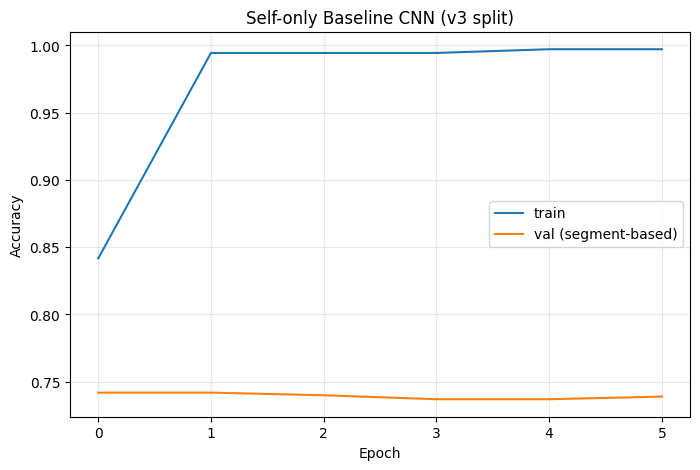

In [5]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=5, restore_best_weights=True
    )
]

history = model.fit(
    X_train, y_train_i,
    validation_data=(X_val, y_val_i),
    epochs=30,
    batch_size=32,
    verbose=1,
    callbacks=callbacks
)

plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val (segment-based)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Self-only Baseline CNN (v3 split)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


TEST accuracy: 0.9682
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step


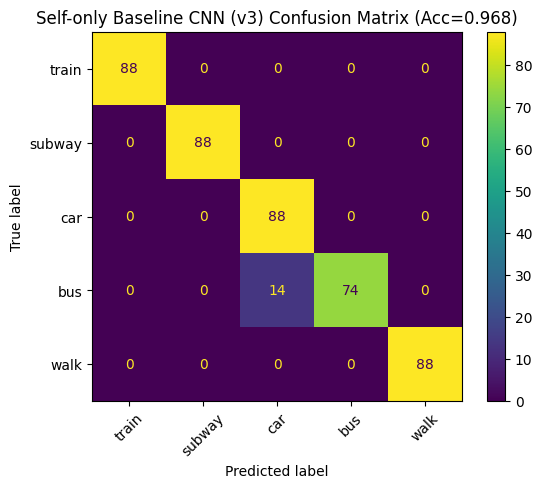


Classification report:
              precision    recall  f1-score   support

       train       1.00      1.00      1.00        88
      subway       1.00      1.00      1.00        88
         car       0.86      1.00      0.93        88
         bus       1.00      0.84      0.91        88
        walk       1.00      1.00      1.00        88

    accuracy                           0.97       440
   macro avg       0.97      0.97      0.97       440
weighted avg       0.97      0.97      0.97       440



In [6]:
test_loss, test_acc = model.evaluate(X_test, y_test_i, verbose=0)
print(f"TEST accuracy: {test_acc:.4f}")

y_pred = np.argmax(model.predict(X_test), axis=1)

cm = confusion_matrix(y_test_i, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=modes)
disp.plot(cmap=None, xticks_rotation=45, values_format="d")
plt.title(f"Self-only Baseline CNN (v3) Confusion Matrix (Acc={test_acc:.3f})")
plt.show()

print("\nClassification report:")
print(classification_report(y_test_i, y_pred, target_names=modes))


Saved model -> self_baseline_v3.h5
Saved confusion matrix -> cm_self_baseline_v3.png


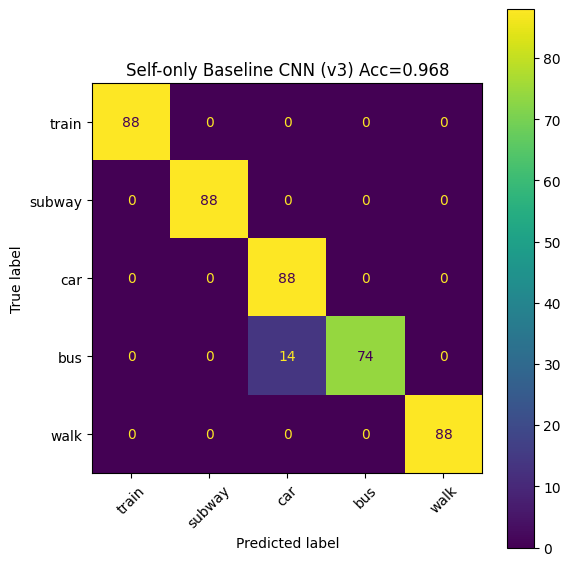

In [7]:
model.save("self_baseline_v3.h5")
print("Saved model -> self_baseline_v3.h5")

# Save confusion matrix as an image
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6,6))
disp = ConfusionMatrixDisplay(confusion_matrix(y_test_i, y_pred), display_labels=modes)
disp.plot(ax=ax, cmap=None, xticks_rotation=45, values_format="d")
ax.set_title(f"Self-only Baseline CNN (v3) Acc={test_acc:.3f}")
fig.tight_layout()
fig.savefig("cm_self_baseline_v3.png", dpi=200)
print("Saved confusion matrix -> cm_self_baseline_v3.png")
